# Test Prompt+Parameter

Im folgenden Abschnitt wird die Entwicklung eines Prompts und Ermittlung der optimalen Parameter für die Generierung der Antworten durch die Large-Language-Modelle anhand einer Stichprobe von zufälligen Beispiel-Fragen aus dem Datensatz durchgeführt. Für die Modell- und Referenz-Antworten wird anschließend eine Messung und ein Vergleich der Ähnlichkeiten mit Hilfe der Vector-Similarity durchgefüht.

Ziel ist die Ermittlung eines Prompts und der optimalen Parameter des LLMs für die Generierung der Antworten, welche im Durchschnitt das beste Ergebnis erzielen.

## Setup

### Pakete laden

In [1]:
import config

import time

import numpy as np
import pandas as pd
import regex as re

import pyarrow as pa
import pyarrow.parquet as pq

from openai import OpenAI

import plotly.graph_objects as go

from util.px import PX
from util.helper import Helper

### Variablen+Funktionen

In [2]:
# Anzahl Beobachtungen für Test
samples = 30

# LLM Parameter
model = 'mistralai/Ministral-8B-Instruct-2410'
#model = 'meta-llama/Llama-3.1-8B-Instruct'

models = ['Ministral-8B-Instruct-2410','Llama-3.1-8B-Instruct']
model_samplings = ['temperature', 'top_p']

model_temperature = 0.1
model_top_p = 0.95

model_file_name = model[model.index('/') + 1:]
model_answer_samples = 3
model_max_tokens = 2048

# Embedding-Modell Parameter
model_embedding = 'nvidia/llama-nemotron-embed-1b-v2'

# OpenAI LLM client
openai_client = OpenAI(
    base_url=config.openai_client['chat']['base_url'],
    api_key=config.openai_client['api_key']
)

# OpenAI Embeddings client
openai_client_embedding = OpenAI(
    base_url=config.openai_client['embedding']['base_url'],
    api_key=config.openai_client['api_key']
)

### Daten laden

Beispiel-Fragen und dazugehörige Referenz-Antworten aus Datensatz laden

In [3]:
# Answers
answers = pd.read_json(f'{config.dataset["path"]}answers.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "answer"})
# Queries
queries = pd.read_json(f'{config.dataset["path"]}queries.json', orient='index', dtype_backend='numpy_nullable')
# Relations
qrels = pd.read_json(f'{config.dataset["path"]}qrels.json', orient='index', dtype_backend='numpy_nullable')

# Neuen Dataframe mit identischem Index aus answers zur Speicherung der Antworten des Modells erzeugen
answers_model = pd.DataFrame({'answer_model': pd.Series(dtype='object'), 'answer_similarity': pd.Series(dtype='object'), 'answer_time': 0.0}, index=answers.index)

### Fragen selektieren

Fragen mit Quelle "Text" und "Text-Tabelle" und mindestens acht Wörtern in der Referenz-Antwort (Fragen mit kurzen Antworten wie "yes" ausschließen) für Ausführung selektieren

source=text|text-table
und word_len>=8

In [4]:
# Fragen und Antworten über Index joinen
queries_answers = queries.merge(answers, how='inner', left_index=True, right_index=True)

# Anzahl Wörter/Frage
queries_answers['answer_replace'] = queries_answers['answer'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
queries_answers['answer_word_count'] = queries_answers['answer_replace'].str.split(' ').str.len()

# Fragen mit source=text|text-table und mindestens 8 Wörtern selektieren
queries_text_text_table = queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] >= 8)]
#queries_text_text_table = queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] > 1)]
#queries_text_text_table = queries_answers.loc[(queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')]

# Zufällige Samples aus Datensatz wählen
queries_text_text_table = queries_text_text_table.sample(n=samples, axis=0, random_state=42)

In [5]:
#queries_text_text_table

## Prompting-Techniken

Die Eingaben generativer KI-Modelle wie LLMs werden auch als Prompts bezeichnet, welche die zu erzeugende Ausgabe leiten bzw. beeinflussen und sich je nach Aufgabe (z.B. Classification, Summarization, Question-Answering) stark unterscheiden. Zusätzlich zur eigentlichen Eingabe, ein Text (z.B. ein zu klassifizierender Tweet oder ein zusammenzufassendes Dokument) oder, bezogen auf die Untersuchung, eine Beispiel-Frage aus dem Datensatz, welche durch das Modell beantwortet werden soll, können bzw. müssen dem Prompt zusätzliche Direktiven zur Lösung der Aufgabe (Klassifizierung/Zusammenfassung des Textes oder Beantwortung der Frage) hinzugefügt werden, welche die eigentliche Kernabsicht darstellen. Für eine Aufgabe wie die Klassifikation eines Textes, wird dem Prompt dabei z.B. neben dem zu klassifizierenden Text eine entsprechende Anweisung wie "Ordne den Text einer des drei folgenden Kategorien positv, neutral oder negativ zu..." hinzugefügt.

Die Gestaltung eines Prompts für eine bestimmte Aufgabe und die Messung von dessen Einfluss auf die Generierung der Ausgabe durch ein Modell ist Gegenstand einer Vielzahl von Untersuchungen. Der Prozess wird in der Literatur mit dem Oberbegriff Prompt-Engineering beschrieben, wobei dieser untergeordnet neben dem Begriff Prompting-Techniques auch einen eigenständigen Teilbereich darstellt.

Beim Prompt-Engineering im engeren Sinne werden i.d.R. automatisierte Verfahren zur Optimierung eines Prompts eingesetzt. Schulhoff liefert eine systematische Erhebung zu Prompt-Engineering Techniken mit Stand Juni 2024 und führt insgesamt 58 text-basierte Prompting-Techniken auf. Aufgrund der hohen Anzahl an verschiedenen Prompting-Techniken und der Gesamt-Komplexität in Bezug auf deren Anwendung, welche den Umfang der Arbeit überschreiten würde, wird nur ein ausgewählter Teil in Frage kommender text-basierter Prompting-Techniken aus den Bereichen In-Context Learning und Thought Generation geprüft und kein Prompt-Engineering im engeren Sinne durchgeführt.

Bei der Prompting-Technik des In-Context Learnings werden mit dem Prompt Beispiele (Zero-/Few-Shot Prompting) und/oder relevante Anweisungen für die zu lösende Aufgabe bereitgestellt und die Fähigkeiten des Modells genutzt, zum Zeitpunkt der Anfrage aus diesen "zu lernen", ohne die Notwendigkeit eines Modelltrainings. Die Prompting-Technik der Thought Generation, bspw. Chain-of-Thought oder Thread-of-Thought, ist angelehnt an die menschliche Vorgehensweise bei der Lösung einer Aufgabe, in dem Sinne, diese zu überdenken, und ihr Ziel ist es, ein LLM dazu zu veranlassen ähnlich dazu Überlegungen/Gedankengänge zu formulieren und in die Lösung der Aufgabe einzubeziehen. Zentral dabei ist eine sogenannte Inducing Phrase (Einleitungssatz) innerhalb des Prompts, welche das gewünschte Verhalten des Modells anstößt.

Für den Test wurden, den gewählten Prompting-Techniken entsprechend, insgesamt 6 Anweisungen (base, style, rephrase, chain_of_thought, thread_of_thought, bias) erstellt und diese in Kombination für eine Stichprobe von 30 Beispiel-Fragen aus dem Datensatz ohne Retrieval in die Sprachmodelle eingegeben. Mit Hilfe der Vector-Similarity wurde anschließend die Ähnlichkeit zwischen den Modell- und Referenz-Antworten berechnet. Zur Berücksichtigung der Varianz der Modell-Ausgabe wurden zu jeder Beispiel-Frage 3 Antworten generiert und aus diesen Durchschnittswerte gebildet.

Neben dem Prompt wird die Ausgabe durch die gewählte Sampling-Methode gesteuert und mit dieser bestimmt, wie ein Sprachmodell das nächste Token wählt. In einem folgenden Schritt wird ein Test der beiden Methoden temperature und top_p mit unterschiedlichen Parameter-Werten durchgeführt und näher auf deren Funktion eingegangen. Im Zusammenhang mit der Entwicklung des Prompts wird für temperature ein moderater Wert von 0.1 und für top_p 0.95 verwendet.

In [5]:
#https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create

model = 'mistralai/Ministral-8B-Instruct-2410'
#model = 'meta-llama/Llama-3.1-8B-Instruct'

model_temperature = 0.1
model_top_p = 0.95

model_file_name = model[model.index('/') + 1:]

prompts = {
    'base': 'Users submit questions regarding various topics and fields related to scientific publications. The aim is to assist users in answering these questions. The answers should be concise and contain only the most important information.',
    'style': 'The questions should be answered in a scientific and objective style.',
    'rephrase': 'If necessary, rephrase and expand the question, then answer it.',
    'chain_of_thought': 'The questions should be thought through logically and answered step by step.',
    'thread_of_thought': 'The questions should be thought through logically, answered step by step, with interim results summarized and analyzed.',
    'bias': 'When answering the questions, various perspectives should be adopted, advantages and disadvantages as well as counterarguments should be stated, and the answers should be formulated neutrally and without value judgments.'
}

prompts_test = [
    '',
    f'{prompts["base"]}',
    f'{prompts["base"]} {prompts["style"]}',
    f'{prompts["base"]} {prompts["rephrase"]}',
    f'{prompts["base"]} {prompts["chain_of_thought"]}',
    f'{prompts["base"]} {prompts["thread_of_thought"]}',
    f'{prompts["base"]} {prompts["bias"]}',
    f'{prompts["base"]} {prompts["style"]} {prompts["rephrase"]} {prompts["chain_of_thought"]} {prompts["bias"]}',
    f'{prompts["base"]} {prompts["style"]} {prompts["rephrase"]} {prompts["thread_of_thought"]} {prompts["bias"]}',
]

prompts_name = [
    'simple',
    'base',
    'baset+style',
    'base+rephrase',
    'base+chain_of_thought',
    'base+thread_of_thought',
    'base+bias',
    'base+style+rephrase+cot+bias',
    'base+style+rephrase+tot+bias'
]

##### Prompts testen

Für alle Test-Prompts in Kombination mit allen Beispiel-Fragen der Stichprobe von 30 Einträgen aus dem Datensatz jeweils 3 Antworten durch die beiden LLMs mit den Sampling-Methoden und Parameter-Werten temperature=0.1 und top_p=0.95 generieren.

Aus der Kombination ergibt sich eine Zahl von 1080 durchzuführenden Iterationen (2 Modelle * 2 Sampling-Methoden * 9 Prompts * 30 Sample), in denen jeweils 3 Antworten generiert werden. Bei einer geschätzten Laufzeit von ca. 5 Sekunden pro Anfrage ergibt sich eine Gesamtzeit von 5400 Sekunden bzw. 1,5 Stunden für die Erzeugung der Ausgabe.

Für jedes Modell, jede Sampling-Methode und jeden Prompt werden die Ergebnisse in einem Dataframe zusammengefasst und im parquet-Format gespeichert.

In [ ]:
# Über Sampling-Methoden iterieren
for s in model_samplings:
    # Über Test-Prompts iterieren
    for j in range(len(prompts_test)):
        print(f'Prompt {j + 1}')
        # Dataframe für Modell-Antworten
        answers_model = pd.DataFrame({'answer_model': pd.Series(dtype='object'), 'answer_similarity': pd.Series(dtype='object'), 'answer_time': 0.0}, index=answers.index)#'temp': 0.0, #pd.Series(dtype='float64')
        # über Fragen iterieren
        for i in range(queries_text_text_table.shape[0]):#samples
            print(f'Frage {i + 1}')
            query = queries_text_text_table.iloc[i]
            # model_answer_samples
            # n Antworten auf Beispiel-Fragen generieren
            time_start = time.time()
            if s == 'temperature':
                response = openai_client.chat.completions.create(
                    model=model,
                    temperature=model_temperature,#t/10,
                    n=model_answer_samples,
                    max_tokens=model_max_tokens,#max_completion_tokens
                    stream=False,
                    messages=[
                        {'role': 'system', 'content': prompts_test[j]}, 
                        {'role': 'user', 'content': query['query']}
                    ],
                )
            elif s == 'top_p':
                response = openai_client.chat.completions.create(
                    model=model,
                    top_p=model_top_p,
                    n=model_answer_samples,
                    max_tokens=model_max_tokens,
                    stream=False,
                    messages=[
                        {'role': 'system', 'content': prompts_test[j]}, 
                        {'role': 'user', 'content': query['query']}
                    ],
                )
            time_end = time.time()
        
            #answers_model.loc[query.name, 'temp'] = t/10
            answers_model.loc[query.name, 'answer_time'] = time_end - time_start
            answers_model.at[query.name, 'answer_model'] = [response.choices[k].message.content for k in range(len(response.choices))]#a
    
            print(time_end - time_start)
        
        # Modell-Antworten im parquet-Format speichern
        answers_model_table = pa.Table.from_pandas(answers_model)
        pq.write_table(answers_model_table, f'{config.dataset["path"]}answers_model_{model_file_name}_samples-{samples}_model_answer_samples-{model_answer_samples}_prompt-{j}_{s}.parquet')#, compression='GZIP'

#### Vector-Similarity

Erzeugung der Text-Emeddings und Berechung der Ähnlichkeit mittels Vector-Similarity zwischen Modell- und Referenz-Antworten für Prompts.

In [ ]:
# Embeddings für Referenz-Antwort erzeugen
embeddings_answer = openai_client_embedding.embeddings.create(
    input=answers.loc[queries_text_text_table.index, 'answer'],#.iloc[0:samples]
    model=model_embedding
)
    
# Über Sampling-Methoden iterieren
for s in model_samplings:
    # Über Test-Prompts iterieren
    for j in range(len(prompts_test)):
    
        # Datei mit Daten für Modell+Prompt laden
        answers_model_file_name = f'{config.dataset["path"]}answers_model_{model_file_name}_samples-{samples}_model_answer_samples-{model_answer_samples}_prompt-{j}_{s}.parquet'#
        answers_model = pq.read_table(answers_model_file_name).to_pandas()
        # Embeddings für Referenz-Antwort erzeugen
        #embeddings_answer_model = openai_client_embedding.embeddings.create(
        #    input=answers_model.loc[queries_text_text_table.index, 'answer_model'],#.iloc[0:samples]
        #    model=model_embedding
        #)
    
        # Über Modell-Antworten iterieren
        for i in range(queries_text_text_table.shape[0]):#samples
            # Embeddings für Modellantworten zu einer Frage erzeugen
            embeddings_answer_model = openai_client_embedding.embeddings.create(
                input=answers_model.loc[queries_text_text_table.iloc[i].name, 'answer_model'],#.iloc[0:samples]
                model=model_embedding
            )

            # Embeddings zu Modell-Antworten in Dataframe speichern
            answers_model.at[queries_text_text_table.iloc[i].name, 'answer_similarity'] = [np.dot(embeddings_answer.data[i].embedding, embeddings_answer_model.data[k].embedding) for k in range(len(embeddings_answer_model.data))]
    
        # Daten speichern
        answers_model_table = pa.Table.from_pandas(answers_model)
        pq.write_table(answers_model_table, answers_model_file_name)#, compression='GZIP'

#### Sample

Erzeugte Modell-Anfworten für Beispiel-Fragen und Referenz-Antworten prüfen

In [7]:
#model = 'mistralai/Ministral-8B-Instruct-2410'
model = 'Llama-3.1-8B-Instruct'
model_sampling = 'temperature'
prompt = 0

dataset_index = 1

# Datei als Dataframe einlesen
answers_model_sample = pq.read_table(f'{config.dataset["path"]}answers_model_{model}_samples-{samples}_model_answer_samples-{model_answer_samples}_prompt-{prompt}_{model_sampling}.parquet').to_pandas()

#print(len(answers_model_sample.loc[queries_text_text_table.iloc[dataset_index].name, 'answer_model'][0]))

# Frage und Referenz-Antwort ausgeben
print('query\n')
print(queries_answers.loc[queries_text_text_table.iloc[dataset_index].name, 'query'])
print('\n---\nanswer\n')
print(queries_answers.loc[queries_text_text_table.iloc[dataset_index].name, 'answer'])

# dazugehörige erste Modell-Antwort ausgeben
print('\n---\nanswer_model\n')
print(answers_model_sample.loc[queries_text_text_table.iloc[dataset_index].name, 'answer_model'][0])
print('\n---\nanswer_similarity\n')
print(answers_model_sample.loc[queries_text_text_table.iloc[dataset_index].name, 'answer_similarity'][0])

query

What happens to the temporal order of events on a spacelike path after Lorentz transformation?

---
answer

The Lorentz transformation does not leave the temporal order invariant, and a sufficiently large spacelike interval can reverse the temporal order of two events.

---
answer_model

In special relativity, when a spacelike path is Lorentz transformed, the temporal order of events on that path can be reversed. 

To understand this, let's consider two events A and B on a spacelike path. In the original frame of reference (let's call it frame S), event A occurs before event B, i.e., A < B.

Now, let's apply a Lorentz transformation to this frame of reference. The Lorentz transformation for spacelike paths involves a boost in the direction of the path. 

After the transformation, the events A and B will be observed in a new frame of reference (let's call it frame S'). In this new frame, the temporal order of events A and B can be reversed, i.e., A > B or B > A.

This means that 

#### Stats

Ergebnisse der Berechung der durchschnittliche Ähnlichkeiten für Modelle, Sampling-Methoden und Prompts darstellen

In [8]:
# Daten einlesen
output = {'model': [], 
'prompt': [], 
'sampling': [], 
'answer_similarity': [], 
'answer': []
}

# Über Modell Sampling-Methode iterieren
for s in model_samplings:#['temperature', 'top_p']
    # Über Modelle iterieren
    for m in models:#['Ministral-8B-Instruct-2410','Llama-3.1-8B-Instruct']
        # Über Test-Prompts iterieren
        for j in range(len(prompts_test)):
            answers_model_file_name = f'{config.dataset["path"]}answers_model_{m}_samples-{samples}_model_answer_samples-{model_answer_samples}_prompt-{j}_{s}.parquet'#m[m.index("/") + 1:]
            answers_model = pq.read_table(answers_model_file_name).to_pandas()
            output['model'].extend([m] * samples)
            output['sampling'].extend([s] * samples)
            output['prompt'].extend([j] * samples)
            output['answer_similarity'].extend(answers_model.loc[queries_text_text_table.index, 'answer_similarity'])
            output['answer'].extend(answers_model.loc[queries_text_text_table.index, 'answer_model'])

# Dataframe erstellen
df = pd.DataFrame.from_dict(output).convert_dtypes()

#df['answer_similarity_median'] = pd.DataFrame(df['answer_similarity'].values.tolist()).median(axis=1)
df['answer_similarity_mean'] = pd.DataFrame(df['answer_similarity'].values.tolist()).mean(axis=1)
df['answer_similarity_min'] = pd.DataFrame(df['answer_similarity'].values.tolist()).min(axis=1)
df['answer_similarity_max'] = pd.DataFrame(df['answer_similarity'].values.tolist()).max(axis=1)
df['answer_similarity_std'] = pd.DataFrame(df['answer_similarity'].values.tolist()).std(axis=1)
df['answer_len'] = pd.DataFrame(df['answer'].values.tolist())[0].str.len()

df = df.sort_values(by=['model', 'sampling', 'prompt'])

#df

In [9]:
df.groupby(by=['model', 'sampling', 'prompt'])['answer_similarity_mean'].describe()

count      mean       std  \
model                      sampling    prompt                              
Llama-3.1-8B-Instruct      temperature 0        30.0  0.621281  0.142031   
                                       1        30.0  0.601402  0.162767   
                                       2        30.0  0.607888  0.148138   
                                       3        30.0  0.626542  0.133667   
                                       4        30.0  0.619317  0.142210   
                                       5        30.0  0.623387  0.134110   
                                       6        30.0  0.612253  0.131547   
                                       7        30.0  0.608365  0.132211   
                                       8        30.0  0.613136  0.131830   
                           top_p       0        30.0  0.607726  0.124407   
                                       1        30.0  0.625926  0.139735   
                                       2        30.0  0.609583  0.139237   
                                       3        30.0  0.630413  0.132630   
                                       4        30.0  0.617222  0.141194   
                                       5        30.0  0.620480  0.133425   
                                       6        30.0  0.612336  0.128712   
                                       7        30.0  0.614728  0.133220   
                                       8        30.0  0.617340  0.124054   
Ministral-8B-Instruct-2410 temperature 0        30.0  0.626937  0.132007   
                                       1        30.0  0.649178  0.162891   
                                       2        30.0  0.636046  0.144137   
                                       3        30.0  0.643037  0.139938   
                                       4        30.0  0.630448  0.137749   
                                       5        30.0  0.621321  0.124396   
                                       6        30.0  0.600852  0.129532   
                                       7        30.0  0.611018  0.126697   
                                       8        30.0  0.614666  0.123372   
                           top_p       0        30.0  0.606272  0.134438   
                                       1        30.0  0.638854  0.145053   
                                       2        30.0  0.618047  0.137297   
                                       3        30.0  0.627957  0.146111   
                                       4        30.0  0.612721  0.138375   
                                       5        30.0  0.608603  0.125896   
                                       6        30.0  0.592365  0.136991   
                                       7        30.0  0.601900  0.129007   
                                       8        30.0  0.601405  0.126543   

                                                    min       25%       50%  \
model                      sampling    prompt                                 
Llama-3.1-8B-Instruct      temperature 0       0.157077  0.558536  0.613833   
                                       1       0.184860  0.543904  0.632898   
                                       2       0.188357  0.544427  0.621911   
                                       3       0.234581  0.549235  0.631570   
                                       4       0.181205  0.538109  0.629566   
                                       5       0.191705  0.585970  0.614509   
                                       6       0.174184  0.563781  0.630923   
                                       7       0.169966  0.563979  0.632643   
                                       8       0.171112  0.551131  0.626353   
                           top_p       0       0.198944  0.552296  0.610827   
                                       1       0.226286  0.553449  0.635473   
                                       2       0.213140  0.566253  0.629032   
                                       3       0.210

#### Bar-Plot, Similarity Modell-/Referenz-Antwort Prompt

Bar-Plot der durchschnittlichen Ähnlichkeiten zwischen Modell- und Referenz-Antwort der Stichprobe für Prompts und verschiedene Sampling-Methoden und Modelle erstellen.

Sampling temperature
Modell Ministral-8B-Instruct-2410
            mean       min       max
prompt                              
0       0.626937  0.203715  0.870090
1       0.649178  0.242388  0.980857
2       0.636046  0.220456  0.887054
3       0.643037  0.203004  0.906441
4       0.630448  0.219047  0.890751
5       0.621321  0.226180  0.824697
6       0.600852  0.182809  0.829550
7       0.611018  0.198451  0.800720
8       0.614666  0.203295  0.789393
Modell Llama-3.1-8B-Instruct
            mean       min       max
prompt                              
0       0.621281  0.157077  0.850644
1       0.601402  0.184860  0.843835
2       0.607888  0.188357  0.843835
3       0.626542  0.234581  0.843965
4       0.619317  0.181205  0.841697
5       0.623387  0.191705  0.839560
6       0.612253  0.174184  0.843835
7       0.608365  0.169966  0.789329
8       0.613136  0.171112  0.797296


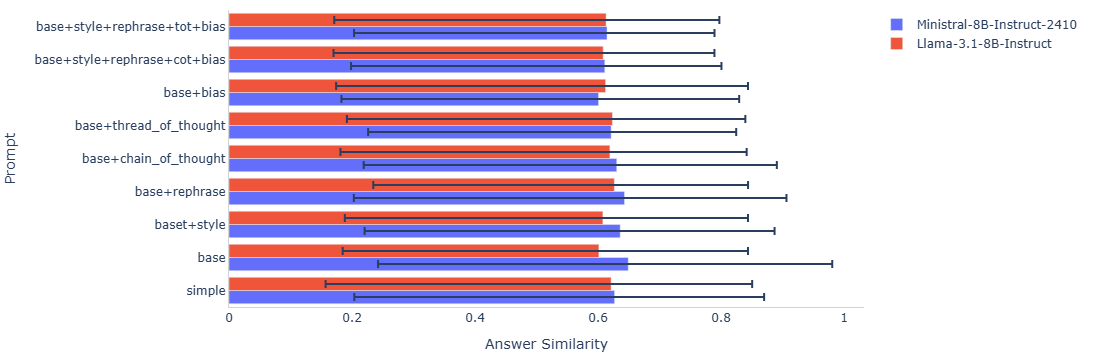

Sampling top_p
Modell Ministral-8B-Instruct-2410
            mean       min       max
prompt                              
0       0.606272  0.192381  0.809476
1       0.638854  0.245390  0.965362
2       0.618047  0.188501  0.876476
3       0.627957  0.216440  0.978429
4       0.612721  0.199303  0.818154
5       0.608603  0.225583  0.809719
6       0.592365  0.193929  0.802630
7       0.601900  0.186384  0.815062
8       0.601405  0.190475  0.796555
Modell Llama-3.1-8B-Instruct
            mean       min       max
prompt                              
0       0.607726  0.198944  0.813493
1       0.625926  0.226286  0.845109
2       0.609583  0.213140  0.842304
3       0.630413  0.210879  0.842895
4       0.617222  0.191296  0.838318
5       0.620480  0.189798  0.821095
6       0.612336  0.208795  0.843600
7       0.614728  0.175498  0.808485
8       0.617340  0.197222  0.783298


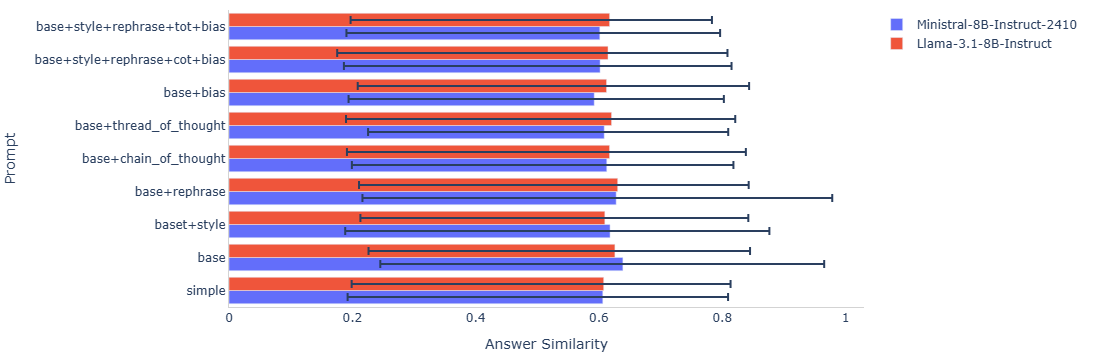

In [10]:
# Sampling-Methoden
for s in model_samplings:
    print(f'Sampling {s}')
    fig = go.Figure()
    # Modelle
    for m in models:
        # Daten für Modell und Sampling-Methode selektieren
        df_group = df.loc[(df['model'] == m) & (df['sampling'] == s)].groupby(by=['prompt'])['answer_similarity_mean']
        df_group_mean = df_group.mean()
        print(f'Modell {m}')
        print(df_group.agg(['mean', 'min', 'max']))
        fig.add_trace(go.Bar(
            y=prompts_name,
            x=df_group_mean,
            name=m,
            orientation='h',
            error_x=dict(type='data', 
                symmetric=False, 
                arrayminus=df_group_mean - df_group.min(), 
                array=df_group.max() - df_group_mean, 
                visible=True
            )
            #marker_color='#3D9970'
        ))
    
    fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor='LightGrey', title='Prompt')
    fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', title='Answer Similarity')
            
    fig.update_layout(
        plot_bgcolor='rgba(255, 255, 255, 1.0)', 
        paper_bgcolor='rgba(255, 255, 255, 1.0)', 
        margin={'l':10, 'b':10, 'r':10, 't':10},
        showlegend=True,
        width=900,
        #height=250,
        #title=f'Answer-Similarity/Prompt, Sampling {s}'
    )
    
    fig.show()

Mit dem Prompt, welcher ausschließlich die Basis-Anweisung enthält (base), wurde für das Modell Ministral-8B-Instruct-2410 und die beiden Sampling-Methoden temperature und top_p die höchste durchschnittliche Ähnlichkeit zwischen den Modell- und Referenz-Antworten aus der Stichprobe mit Werten von 0.649 und 0.639 berechnet. Für das Modell Llama-3.1-8B-Instruct und die Sampling-Methode top_p wurde mit dem gleichen Prompt und einem Wert von 0.626 das zweitbeste Ergebnis und für die Sampling-Methode temperature mit 0.601 dem gegenüber das schlechteste Ergebnis erzielt.

In [ ]:
#df.loc[((df['model'] == 'Ministral-8B-Instruct-2410') & (df['sampling'] == 'temperature') & (df['prompt'] == 0)), 'answer_similarity_mean'].mean()

#### Box-Plot, Similarity Modell-/Referenz-Antwort Prompt

Box-Plot der Verteilung der Werte für die Ähnlichkeiten zwischen Modell- und Referenz-Antwort der Stichprobe für Prompts und verschiedene Sampling-Methoden und Modelle erstellen.

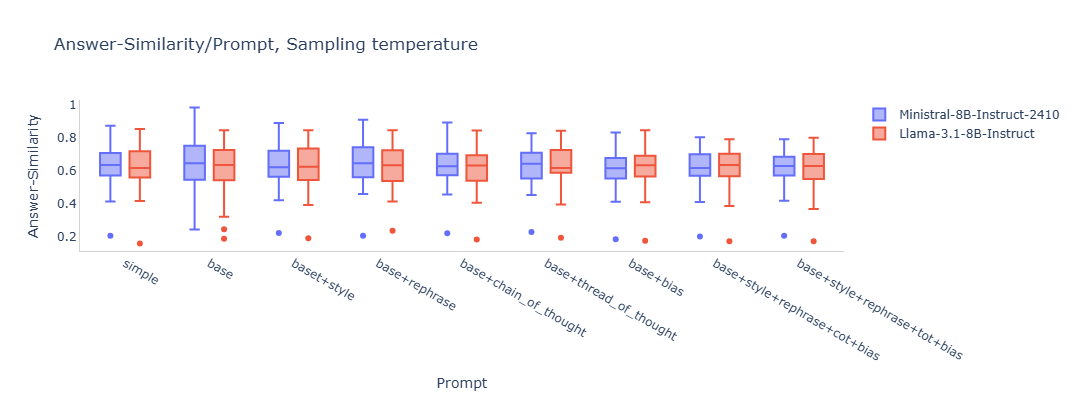

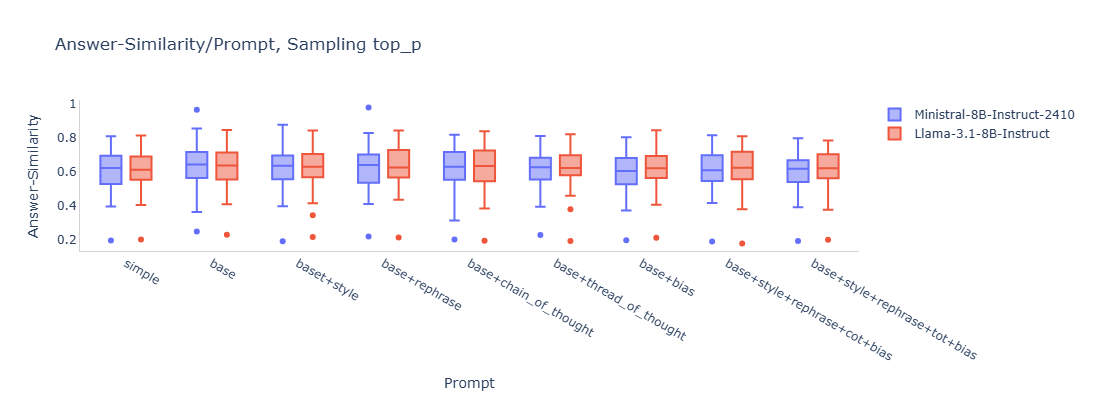

In [11]:
# Boxplot, Similarity Modell-Antworten/Referenz-Antwort pro Prompt (min, max, mean)

for s in model_samplings:

    fig = go.Figure()
    
    for m in models:
        fig.add_trace(go.Box(
            x=df.loc[(df['model'] == m) & (df['sampling'] == s), 'prompt'].to_list(),
            y=df.loc[(df['model'] == m) & (df['sampling'] == s), 'answer_similarity_mean'].to_list(),
            name=m,
            #marker_color='#3D9970'
        ))
    
    fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor='LightGrey', title='Answer-Similarity')
    fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', title='Prompt', tickmode="array", tickvals=list(range(len(prompts_test))), ticktext=prompts_name)
            
    fig.update_layout(
        width=900,
        height=400,
        plot_bgcolor='rgba(0, 0, 0, 0)', 
        paper_bgcolor='rgba(0, 0, 0, 0)', 
        #margin={'l':0, 'b':0, 'r':0, 't':0},
        showlegend=True,
        title=f'Answer-Similarity/Prompt, Sampling {s}',
        boxmode='group'
    )
    
    fig.show()

Bei Betrachtung der Verteilung der durchschnittlichen Ähnlichkeiten für beide Modelle und Sampling-Methoden liegen für den Prompt mit der Basis-Anweisung 50% der Werte 

## Sampling-Methoden

Die Sampling-Methode temperature greift in die rohen Score-Werte (Logits) vor der Softmax-Wahrscheinlichkeitsberechnung ein und verändert die Wahrscheinlichkeiten. Die Parameter-Werte können im Bereich von 0 bis 2 liegen, wobei höhere Werte die Verteilung abflachen und zur Auswahl weniger wahrscheinlicher Token und damit einem zufälligeren Ergebnis führen. Ein Wert von 0.0 hingegen würde beispielsweise immer zur Auswahl des wahrscheinlichsten Tokens führen und sich das Modell damit deterministisch verhalten und eine bestimmte Eingabe immer zur gleichen Ausgabe führen. Der Wert des Parameters top_p gibt die Höhe der kummulierten Wahrscheinlichkeit an, welche die nächst wahrscheinlichen Token umfasst und schränkt damit die Auswahl der möglichen Token ein. Bei einem Wert von 0.05 werden die Token gewählt, welche zusammen 5% der oberen Wahrscheinlichkeitsmasse ausmachen.

### Parameter-Test

Für eine Auswahl von Parameterwert-Kombinationen der beiden Sampling-Methoden werden unter Verwendung des gewählten Prompts mit der Basis-Anweisung und der gleichen Stichprobe durch die beiden Modelle wieder jeweils 3 Antworten erstellt. Höhere Parameterwerte für die Sampling-Methode temperature führen zu einem zufälligeren Ergebnis, für die zu generierenden Antworten sollte dieser nicht zu hoch gewählt werden und es wird der Bereich von 0.0 bis 0.4 getestet. Zur Prüfung der Auswirkung unterschiedlicher Werte für die Sampling-Methode top_p auf die Erzeugung der Ausgabe, wird für den Parameter ein großer Bereich von 0.1 bis 1.0 getestet.

In [12]:
model = 'mistralai/Ministral-8B-Instruct-2410'
#model = 'meta-llama/Llama-3.1-8B-Instruct'

model_sampling_values = [[i/10 for i in range(5)], [i/10 for i in range(1,11)]]#temperature, top_p

model_file_name = model[model.index('/') + 1:]

In [ ]:
# Über Sampling-Methoden iterieren
for j in range(len(model_samplings)):
    s = model_samplings[j]
    print(f'Sampling {s}')
    # Über Werte für Sampling-Methoden iterieren
    for k in model_sampling_values[j]:
        print(f'Value {k}')
        # Dataframe für Modell-Antworten
        answers_model = pd.DataFrame({'answer_model': pd.Series(dtype='object'), 'answer_similarity': pd.Series(dtype='object'), 'answer_time': 0.0}, index=answers.index)#'temp': 0.0, #pd.Series(dtype='float64')
        # über Fragen iterieren
        for i in range(queries_text_text_table.shape[0]):#samples
            print(f'Frage {i + 1}')
            query = queries_text_text_table.iloc[i]
            # Antworten zu Beispiel-Fragen generieren
            time_start = time.time()
            if s == 'temperature':
                response = openai_client.chat.completions.create(
                    model=model,
                    temperature=k,
                    n=1 if k == 0.0 else model_answer_samples,
                    max_tokens=model_max_tokens,#max_completion_tokens
                    stream=False,
                    messages=[
                        {'role': 'system', 'content': prompts_test[1]}, 
                        {'role': 'user', 'content': query['query']}
                    ],
                )
            elif s == 'top_p':
                response = openai_client.chat.completions.create(
                    model=model,
                    top_p=k,
                    n=model_answer_samples,
                    max_tokens=model_max_tokens,#max_completion_tokens
                    stream=False,
                    messages=[
                        {'role': 'system', 'content': prompts_test[1]}, 
                        {'role': 'user', 'content': query['query']}
                    ],
                )
            time_end = time.time()
        
            #answers_model.loc[query.name, 'temp'] = t/10
            answers_model.loc[query.name, 'answer_time'] = time_end - time_start
            answers_model.at[query.name, 'answer_model'] = [response.choices[k].message.content for k in range(len(response.choices))]#a
    
            print(time_end - time_start)
        
        # Modell-Antworten im parquet-Format speichern
        answers_model_table = pa.Table.from_pandas(answers_model)
        pq.write_table(answers_model_table, f'{config.dataset["path"]}answers_model_{model_file_name}_samples-{samples}_model_answer_samples-{model_answer_samples}_prompt-1_{s}_{k}.parquet')#, compression='GZIP'

#### Vector-Similarity

Erzeugung der Text-Emeddings und Berechung der Ähnlichkeit mittels Vector-Similarity zwischen Modell- und Referenz-Antworten für Parameter-Wert-Kombinationen.

In [ ]:
# Embeddings für Referenz-Antwort erzeugen
embeddings_answer = openai_client_embedding.embeddings.create(
    input=answers.loc[queries_text_text_table.index, 'answer'],#.iloc[0:samples]
    model=model_embedding
)

# Über Sampling-Methoden iterieren
for j in range(len(model_samplings)):
    s = model_samplings[j]
    # Über Werte für Sampling-Methode iterieren
    for k in model_sampling_values[j]:
        # Datei mit Daten für Modell+Prompt laden
        answers_model_file_name = f'{config.dataset["path"]}answers_model_{model_file_name}_samples-{samples}_model_answer_samples-{model_answer_samples}_prompt-1_{s}_{k}.parquet'#
        answers_model = pq.read_table(answers_model_file_name).to_pandas()
    
        # Über sample iterieren
        for i in range(queries_text_text_table.shape[0]):#samples
            # Embeddings für Modellantworten zu einer Frage erzeugen
            embeddings_answer_model = openai_client_embedding.embeddings.create(
                input=answers_model.loc[queries_text_text_table.iloc[i].name, 'answer_model'],#.iloc[0:samples]
                model=model_embedding
            )
            
            answers_model.at[queries_text_text_table.iloc[i].name, 'answer_similarity'] = [np.dot(embeddings_answer.data[i].embedding, embeddings_answer_model.data[k].embedding)for k in range(len(embeddings_answer_model.data))]
        
        # Daten speichern
        answers_model_table = pa.Table.from_pandas(answers_model)
        pq.write_table(answers_model_table, answers_model_file_name)#, compression='GZIP'

#### Stats

Ergebnisse der Berechung der durchschnittliche Ähnlichkeiten für Modelle, Sampling-Methoden und dazugehörige Wertebereiche darstellen

In [13]:
# Daten einlesen
output = {'model': [], 
'sampling': [], 
'value': [], 
'answer_similarity_mean': [], 
'answer_similarity_min': [], 
'answer_similarity_max': []
}

# Über Modell Sampling-Methoden iterieren
for j in range(len(model_samplings)):
    s = model_samplings[j]
    # Über Modelle iterieren
    for m in models:
        # Über Werte für Sampling-Methode iterieren
        for k in model_sampling_values[j]:
            answers_model_file_name = f'{config.dataset["path"]}answers_model_{m}_samples-{samples}_model_answer_samples-{model_answer_samples}_prompt-1_{s}_{k}.parquet'
            answers_model = pq.read_table(answers_model_file_name).to_pandas()
            output['model'].append(m)
            output['sampling'].append(s)
            output['value'].append(k)
            output['answer_similarity_mean'].append(pd.DataFrame(answers_model.loc[queries_text_text_table.index, 'answer_similarity'].values.tolist()).mean(axis=1).mean())
            output['answer_similarity_min'].append(pd.DataFrame(answers_model.loc[queries_text_text_table.index, 'answer_similarity'].values.tolist()).min(axis=1).min())
            output['answer_similarity_max'].append(pd.DataFrame(answers_model.loc[queries_text_text_table.index, 'answer_similarity'].values.tolist()).max(axis=1).max())#

# Dataframe erstellen
df = pd.DataFrame.from_dict(output).convert_dtypes()

df = df.sort_values(by=['model', 'sampling', 'value'])

#df

In [14]:
#df_group = df.groupby(by=['model', 'sampling', 'value'])['answer_similarity_mean'].agg(answer_similarity_mean='mean', answer_similarity_min='min', answer_similarity_max='max').reset_index()

#### Scatter Line Plot Modell Sampling-Methode

Darstellung der erzielten durchschnittlichen Ähnlichkeitswerte für Modelle, Sampling-Methoden und Parameter-Werte als Scatter Line Plot

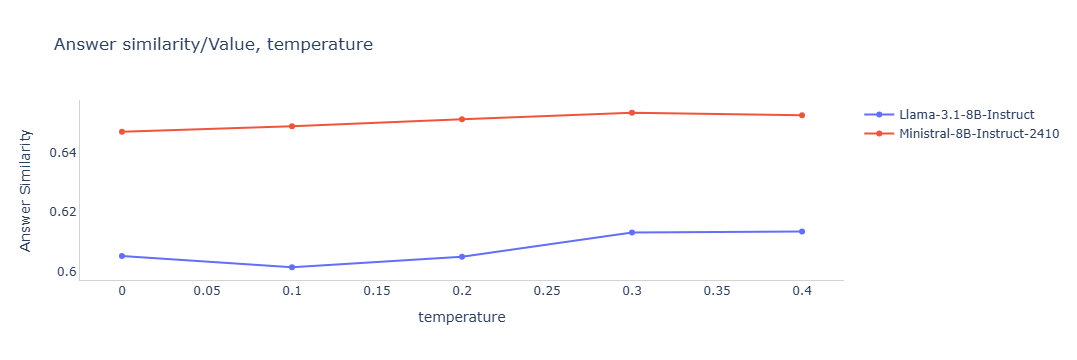

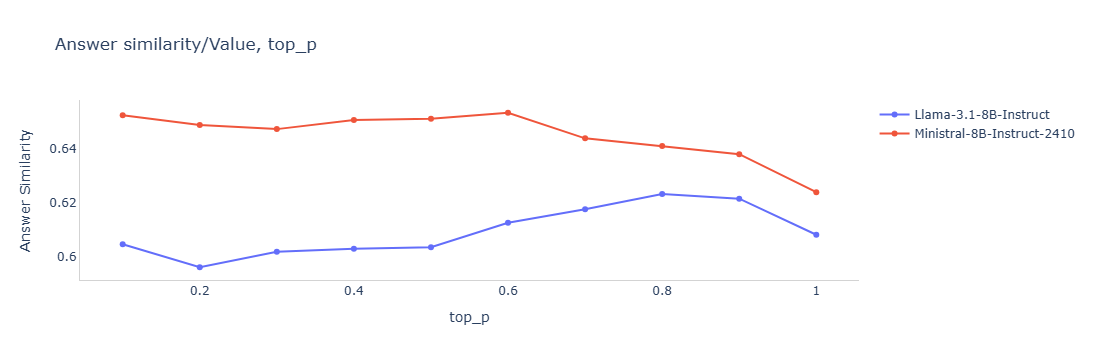

In [15]:
PX.scatter_line_multi(
    #df_group.loc[df_group['sampling'] == 'temperature'], 
    df.loc[df['sampling'] == 'temperature'], 
    'model', 
    'value', 
    'answer_similarity_mean', 
    'Answer similarity/Value, temperature', 
    xaxes={'title':'temperature'}, 
    yaxes={'range':None, 'title':'Answer Similarity'}
)#[0.0, 0.8]

PX.scatter_line_multi(
    #df_group.loc[df_group['sampling'] == 'top_p'], 
    df.loc[df['sampling'] == 'top_p'], 
    'model', 
    'value', 
    'answer_similarity_mean', 
    'Answer similarity/Value, top_p', 
    xaxes={'title':'top_p'}, 
    yaxes={'range':None, 'title':'Answer Similarity'}
)#[0.0, 0.8]

Mit der Sampling-Methode temperature und dem Parameter-Wert 0.3 wurde für das Modell Ministral-8B-Instruct-2410 die höchste durchschnittliche Ähnlichkeit mit einem Wert von 0.653 und für das Modell Llama-3.1-8B-Instruct mit 0.613 der zweithöchste Wert erzielt. Für beide Modelle steigt die berechnete Ähnlichkeit mit Erhöhrung der Parameter-Werte bis 0.3 an und bleibt in der Folge konstant.

Für die Sampling-Methode top_p verlaufen die Kurven zwischen beiden Modelle unterschiedlich. Im Bereich von 0.1-0.6 der Parameter-Werte verläuft diese für das Modell Ministral-8B-Instruct-2410 relativ konstant und fällt anschließend ab. Nach einem anfänglichen Abfallen der Kurve steigt sie für das Modell Llama-3.1-8B-Instruct bis zum Parameter-Wert 0.8 an und fällt daraufhin erneut ab.

Um die Ergebnisse der Experimente vergleichen zu können, wird für beide Modelle der gleiche Prompt sowie die gleiche Sampling-Methode gewählt. Auf Grundlage der in den Tests ermittelten Werte wird der Prompt, welcher die Basis-Anweisung enthält sowie die Samping-Methode temperature mit einem Wert von 0.3 für die Durchführung der Untersuchung verwendet.

#### Scatter Line Plot Modell Sampling-Methode (min, max, mean)

Darstellung der erzielten durchschnittlichen sowie minimalen und maximalen Ähnlichkeitswerte für Modelle, Sampling-Methoden und Parameter-Werte als Scatter Line Plot

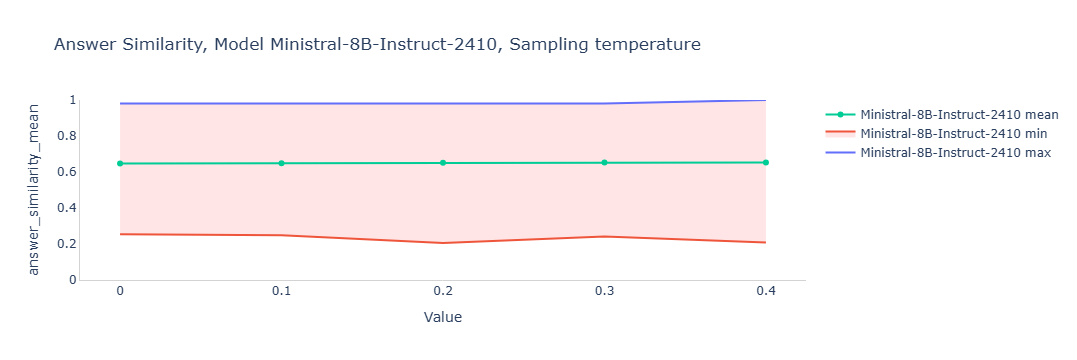

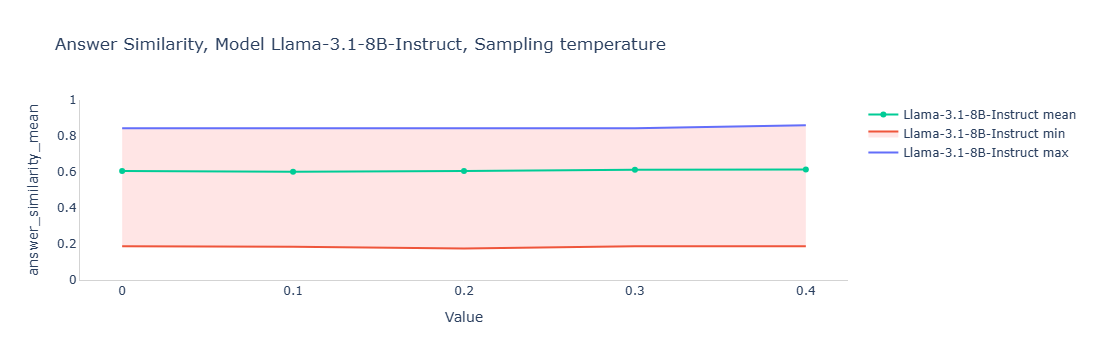

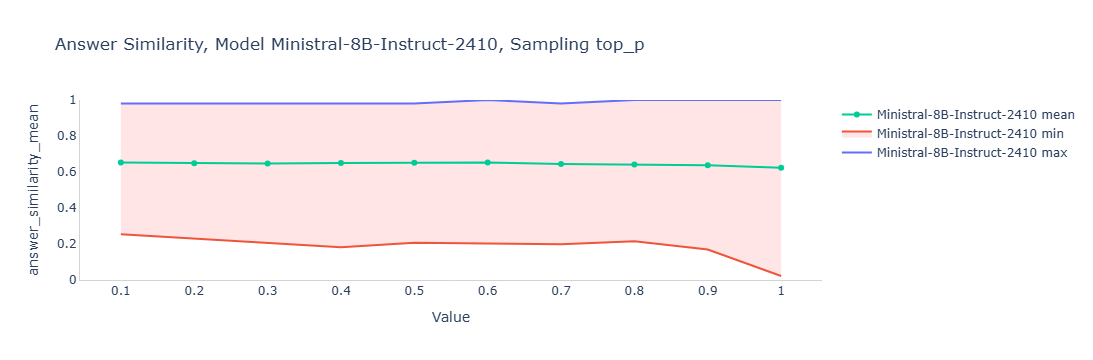

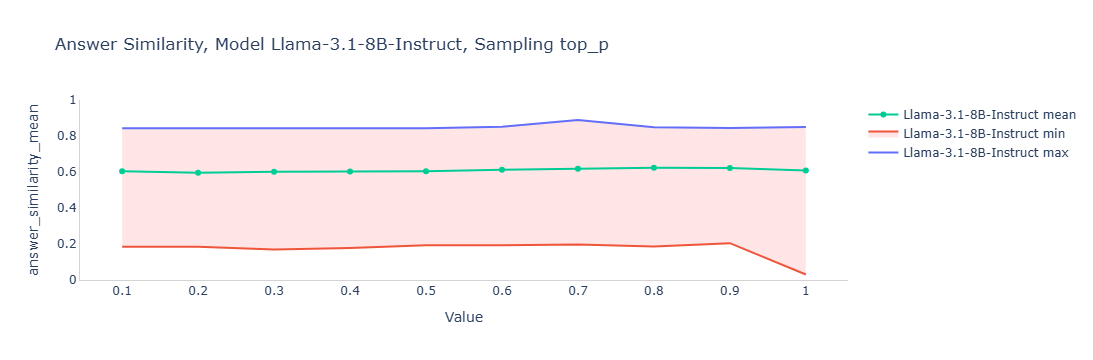

In [16]:
for s in model_samplings:
    #for entry in df['model'].unique():
    for entry in models:#['Ministral-8B-Instruct-2410','Llama-3.1-8B-Instruct']:
        fig = go.Figure()
        
        fig.add_trace(go.Scatter(x=df.loc[(df['model'] == entry) & (df['sampling'] == s), 'value'], 
            y=df.loc[(df['model'] == entry) & (df['sampling'] == s), 'answer_similarity_max'], 
            name=f'{entry} max',
            mode='lines+text',
            #text=df_gdfroup.loc[df['model'] == entry, 'answer_char_count_max'],
            textposition='top left')
        )
        fig.add_trace(go.Scatter(x=df.loc[(df['model'] == entry) & (df['sampling'] == s), 'value'], 
            y=df.loc[(df['model'] == entry) & (df['sampling'] == s), 'answer_similarity_min'], 
            name=f'{entry} min',
            mode='lines+text',
            #text=df.loc[df['model'] == entry, 'answer_char_count_min'],#'Zeichen avg: ' + 
            textposition='middle left',
            fill='tonexty',
            fillcolor='rgba(255, 0, 0, 0.1)')
        )
        fig.add_trace(go.Scatter(x=df.loc[(df['model'] == entry) & (df['sampling'] == s), 'value'], 
            y=df.loc[(df['model'] == entry) & (df['sampling'] == s), 'answer_similarity_mean'], 
            name=f'{entry} mean',
            #text=df.loc[df['model'] == entry, 'answer_char_count_mean'],
            textposition='bottom left',
            #textfont={'color': '#E58606'},
            #marker={'color': '#5D69B1'},
            #line={'color': '#52BCA3', 'width': 1, 'dash': 'dash'},
            mode='lines+markers+text')
        )
        
        fig.update_yaxes(showline=True, linewidth=1, linecolor='LightGrey', showgrid=False, title='answer_similarity_mean', range=[0.0, 1.0])#
        fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', showgrid=False, title='Value', dtick = 0.1)##, tick0 = -0., range=[-0.1, 0.4]
        
        fig.update_layout(plot_bgcolor='rgba(0, 0, 0, 0)', 
            paper_bgcolor='rgba(0, 0, 0, 0)', 
            #margin={'l':0, 'b':0, 'r':0, 't':0},
            title=f'Answer Similarity, Model {entry}, Sampling {s}',
            showlegend=True)#
        
        fig.show()